**Zachary Torstrick**  
**ATMS 523**  
**HW 6**  
**Fall 2025**  

#### Datasets

Use the Storm Prediction Center tornado dataset https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv

Also, use the ENSO, PDO, NAO, and AO dataframe from earlier module.

In [188]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import shap

from data_utils import load_data
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

1\. Aggregate the tornado data over the following states into a monthly count of tornadoes:
   - Illinois

In [189]:
tornado_data = load_data(
    "https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv",
    "data/1950-2021_actual_tornadoes.csv"
)

# use only Illinois
tornado_illinois = tornado_data[tornado_data['st'] == 'IL'].copy()

# set date index
tornado_illinois.set_index('date', inplace=True)
tornado_illinois.index = pd.to_datetime(tornado_illinois.index)

# Resample to monthly counts - create a 'tornado_count' column
tornado_monthly = tornado_illinois.resample('MS').size().to_frame(name='tornado_count')

tornado_monthly.head(10)


Using saved file: data/1950-2021_actual_tornadoes.csv


,tornado_count
date,
1950-01-01,2
1950-02-01,0
1950-03-01,1
1950-04-01,0
1950-05-01,0
1950-06-01,1
1950-07-01,1
1950-08-01,0
1950-09-01,0


2\. Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [190]:
# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Load climate data
widths = [4] + [6]*12
enso = pd.read_fwf(
    'data/soi.dat',
    widths=widths,
    skiprows=4,
    header=None,
    na_values=[-99.9],
)

pdo = load_data(
    'https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.pdo.dat',
    'data/pdo.dat',
    sep=r'\s+',
    header=None,
    skiprows=2,
    engine='python'
)

nao = load_data(
    'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',
    'data/nao.dat',
    sep=r'\s+',
    header=None,
    skiprows=1,
    engine='python'
)

ao = load_data(
    'https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii.table',
    'data/ao.dat',
    sep=r'\s+',
    header=None,
    skiprows=1,
    engine='python'
)

enso_new = pd.DataFrame()
enso_new['Date'] = pd.date_range(
    start=datetime.datetime(int(enso[0].iloc[0]), 1, 1),
    end=datetime.datetime(int(enso[0].iloc[-1]), 12, 1),
    freq="MS"
)
enso_new = enso_new.set_index('Date')
enso_new['ENSO'] = enso.loc[:, 1:].stack(future_stack=True).values
enso_new.loc[enso_new['ENSO'] <= -9.9, 'ENSO'] = np.nan

pdo_new = pd.DataFrame()
pdo_new['Date'] = pd.date_range(
    start=datetime.datetime(int(pdo[0].iloc[0]), 1, 1),
    end=datetime.datetime(int(pdo[0].iloc[-1]), 12, 1),
    freq="MS"
)
pdo_new = pdo_new.set_index('Date')
pdo_new['PDO'] = pdo.loc[:, 1:].stack(future_stack=True).values
pdo_new.loc[pdo_new['PDO'] > 90., 'PDO'] = np.nan

nao_new = pd.DataFrame()
nao_new['Date'] = pd.date_range(
    start=datetime.datetime(int(nao[0].iloc[0]), 1, 1),
    end=datetime.datetime(int(nao[0].iloc[-1]), 12, 1),
    freq="MS"
)
nao_new = nao_new.set_index('Date')
nao_new['NAO'] = nao.loc[:, 1:].stack(future_stack=True).values
nao_new.loc[nao_new['NAO'] <= -99.9, 'NAO'] = np.nan

ao_new = pd.DataFrame()
ao_new['Date'] = pd.date_range(
    start=datetime.datetime(int(ao[0].iloc[0]), 1, 1),
    end=datetime.datetime(int(ao[0].iloc[-1]), 12, 1),
    freq="MS"
)
ao_new = ao_new.set_index('Date')
ao_new['AO'] = ao.loc[:, 1:].stack(future_stack=True).values
ao_new.loc[ao_new['AO'] <= -99.9, 'AO'] = np.nan

# Merge all climate indices together (ENSO excluded for now)
merged = pd.merge(enso_new, pdo_new, left_index=True, right_index=True)
merged = pd.merge(merged, nao_new, left_index=True, right_index=True)
merged = pd.merge(merged, ao_new, left_index=True, right_index=True)
merged = pd.merge(merged, tornado_monthly, left_index=True, right_index=True)

Using saved file: data/pdo.dat
Using saved file: data/nao.dat
Using saved file: data/ao.dat


3\. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.



RMSE: 2.824
Correlation coefficient (r): 0.970


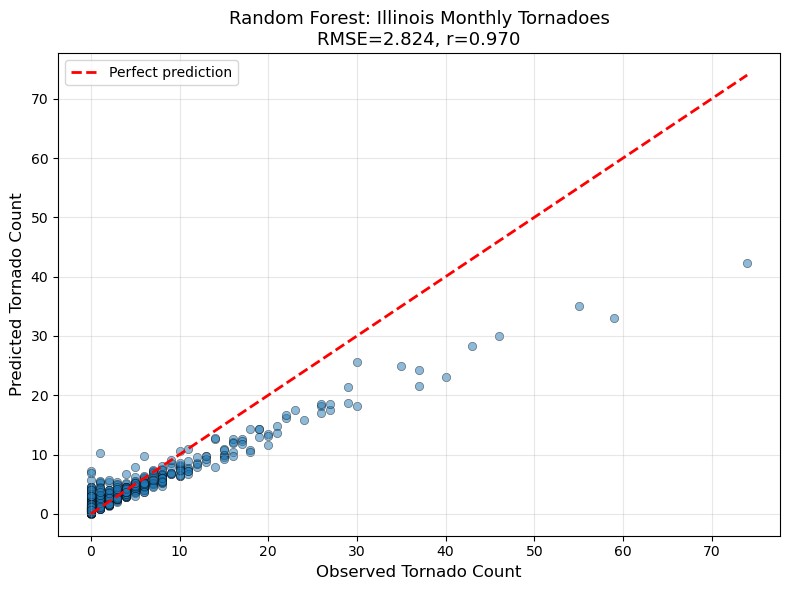

In [191]:
# Prepare data
illinois_climate_data = merged.dropna()

# Features
X = illinois_climate_data[['PDO', 'NAO', 'AO', 'ENSO']]

# Target: tornado counts
y = illinois_climate_data['tornado_count']

# Create and train Random Forest regression model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X, y)

# Make predictions
y_pred = rf_model.predict(X)

# Calculate metrics
rmse = root_mean_squared_error(y, y_pred)
corr, p_value = pearsonr(y, y_pred)

# Report results
print(f"RMSE: {rmse:.3f}")
print(f"Correlation coefficient (r): {corr:.3f}")

# Create scatter plot of predicted vs observed
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Observed Tornado Count', fontsize=12)
plt.ylabel('Predicted Tornado Count', fontsize=12)
plt.title(f'Random Forest: Illinois Monthly Tornadoes\nRMSE={rmse:.3f}, r={corr:.3f}', 
          fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

4\. Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.



Q3 (climate only):    RMSE = 2.824, r = 0.970
Q4 (climate + month): RMSE = 2.581, r = 0.955
Comparison:           ΔRMSE = 0.243, Δr = -0.015


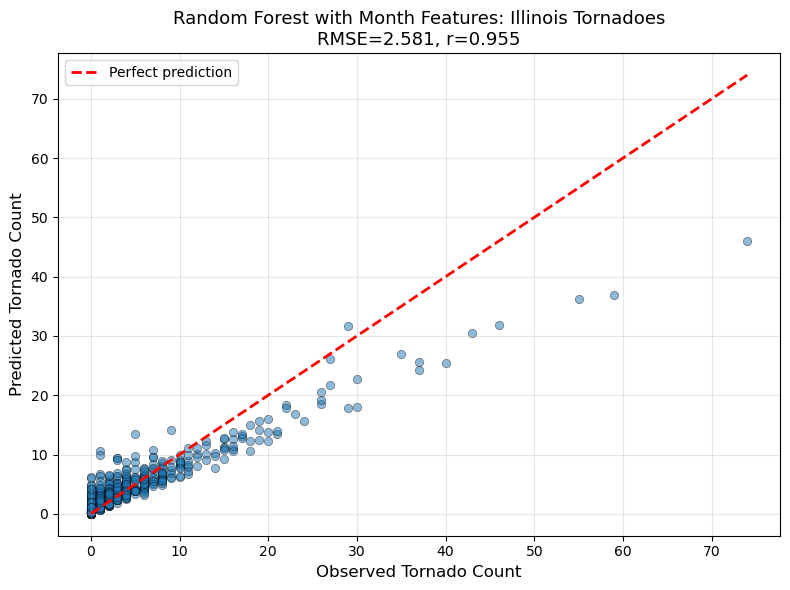

In [192]:
# Prepare clean data
data_clean = merged.dropna().copy()

# Extract month from the date index
months = data_clean.index.month.values.reshape(-1, 1)

# One-hot encode months
encoder = OneHotEncoder(sparse_output=False, drop=None)
month_encoded = encoder.fit_transform(months)

# Create month name mapping
month_map = {1: 'January', 2: 'February', 3: 'March', 4: 'April',
             5: 'May', 6: 'June', 7: 'July', 8: 'August',
             9: 'September', 10: 'October', 11: 'November', 12: 'December'}

# Map encoder categories to month names
month_names = [month_map[int(category)] for category in encoder.categories_[0]]

# Combine climate indices with month features
X_with_month = pd.concat([
    data_clean[['PDO', 'NAO', 'AO', 'ENSO']],
    pd.DataFrame(month_encoded, columns=month_names, index=data_clean.index)
], axis=1)

# Target
y_with_month = data_clean['tornado_count'].values

# Train Random Forest with month features
rf_model_month = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model_month.fit(X_with_month, y_with_month)

# Make predictions
y_pred_month = rf_model_month.predict(X_with_month)

# Calculate metrics
rmse_month = root_mean_squared_error(y_with_month, y_pred_month)
corr_month, p_value_month = pearsonr(y_with_month, y_pred_month)

# Report results and comparison
print(f"Q3 (climate only):    RMSE = {rmse:.3f}, r = {corr:.3f}")
print(f"Q4 (climate + month): RMSE = {rmse_month:.3f}, r = {corr_month:.3f}")
print(f"Comparison:           ΔRMSE = {rmse - rmse_month:.3f}, Δr = {corr_month - corr:.3f}")

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_with_month, y_pred_month, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_with_month.min(), y_with_month.max()], 
         [y_with_month.min(), y_with_month.max()], 
         'r--', lw=2,
         label='Perfect prediction')
plt.xlabel('Observed Tornado Count', fontsize=12)
plt.ylabel('Predicted Tornado Count', fontsize=12)
plt.title(
    f'Random Forest with Month Features: Illinois Tornadoes\nRMSE={rmse_month:.3f}, r={corr_month:.3f}', 
    fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


5\. Perform a feature importance and multipass permutation analysis of your features.


Random Forest Feature Importances (MDI):
------------------------------------------------------------
AO           0.222587
NAO          0.217895
PDO          0.179422
ENSO         0.171159
May          0.069193
June         0.061491
April        0.050917
August       0.005912
December     0.005405
March        0.004786
July         0.004512
November     0.002567
February     0.001882
September    0.001320
October      0.000566
January      0.000386
dtype: float64

Permutation Importance (10 repeats):
------------------------------------------------------------

Feature			Mean Importance		Std Dev
May                 	0.445363		0.059844
April               	0.382388		0.044523
ENSO                	0.368192		0.049964
AO                  	0.358792		0.048626
NAO                 	0.327298		0.031634
June                	0.318061		0.027220
PDO                 	0.224398		0.022528
August              	0.079679		0.010083
July                	0.030754		0.002761
March               	0.017468		0.001

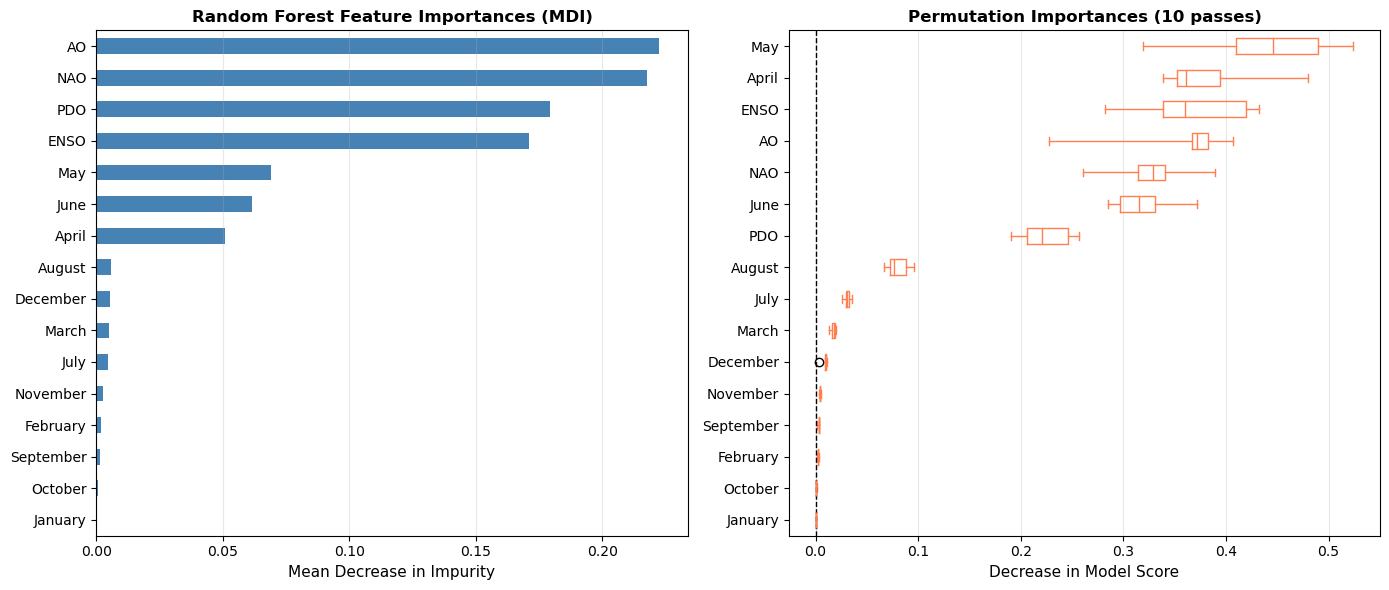


Comparison of Top 5 Features:
------------------------------------------------------------

MDI Importance (Top 5):
1. AO                  : 0.222587
2. NAO                 : 0.217895
3. PDO                 : 0.179422
4. ENSO                : 0.171159
5. May                 : 0.069193

Permutation Importance (Top 5):
1. May                 : 0.445363
2. April               : 0.382388
3. ENSO                : 0.368192
4. AO                  : 0.358792
5. NAO                 : 0.327298


In [193]:
# Mean Decrease in Impurity (MDI) Feature Importance
print("Random Forest Feature Importances (MDI):")
print("-" * 60)

# Get feature importances from the trained model
mdi_importances = pd.Series(
    rf_model_month.feature_importances_,
    index=X_with_month.columns
).sort_values(ascending=False)

print(mdi_importances)

# Plot MDI importances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

mdi_importances.sort_values(ascending=True).plot.barh(ax=ax1, color='steelblue')
ax1.set_title("Random Forest Feature Importances (MDI)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Mean Decrease in Impurity", fontsize=11)
ax1.grid(axis='x', alpha=0.3)

# Permutation Importance (multipass with n_repeats=10)
print("\nPermutation Importance (10 repeats):")
print("-" * 60)

# Calculate permutation importance with multiple passes
perm_importance = permutation_importance(
    rf_model_month,
    X_with_month,
    y_with_month,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create DataFrame with results
perm_importances_mean = pd.Series(
    perm_importance.importances_mean,
    index=X_with_month.columns
).sort_values(ascending=False)

perm_importances_std = pd.Series(
    perm_importance.importances_std,
    index=X_with_month.columns
)

print("\nFeature\t\t\tMean Importance\t\tStd Dev")
for feature in perm_importances_mean.index:
    print(f"{feature:20s}\t{perm_importances_mean[feature]:.6f}\t\t{perm_importances_std[feature]:.6f}")

# Plot permutation importances with error bars
sorted_idx = perm_importance.importances_mean.argsort()
perm_df = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X_with_month.columns[sorted_idx]
)

perm_df.plot.box(vert=False, whis=10, ax=ax2, color='coral')
ax2.set_title("Permutation Importances (10 passes)", fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='k', linestyle='--', linewidth=1)
ax2.set_xlabel("Decrease in Model Score", fontsize=11)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# comparison
print("\nComparison of Top 5 Features:")
print("-" * 60)
print("\nMDI Importance (Top 5):")
for i, (feature, importance) in enumerate(mdi_importances.head(5).items(), 1):
    print(f"{i}. {feature:20s}: {importance:.6f}")

print("\nPermutation Importance (Top 5):")
for i, (feature, importance) in enumerate(perm_importances_mean.head(5).items(), 1):
    print(f"{i}. {feature:20s}: {importance:.6f}")


6\. Create a SHAP Summary Plot showing feature importance and feature effects.

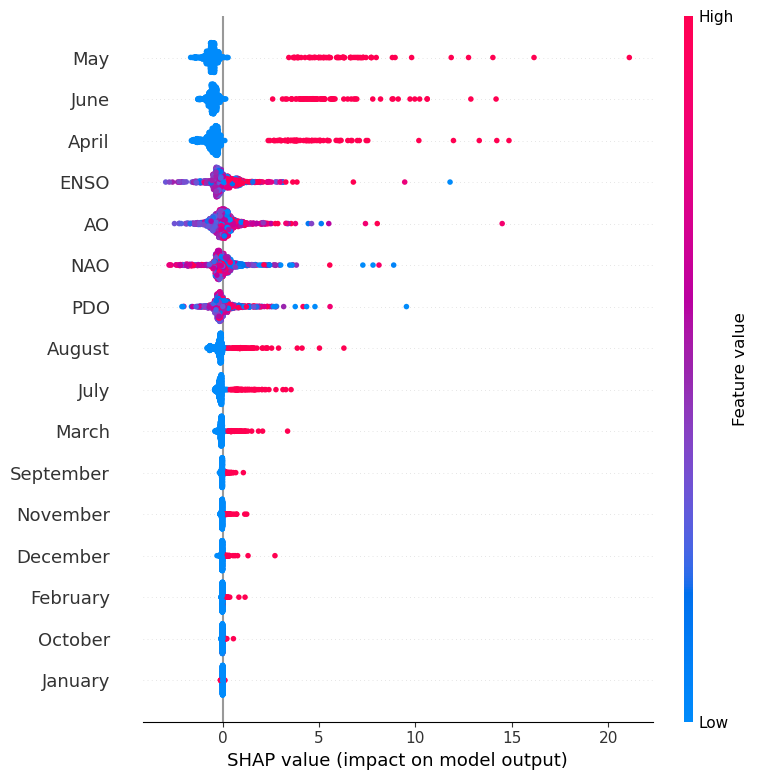

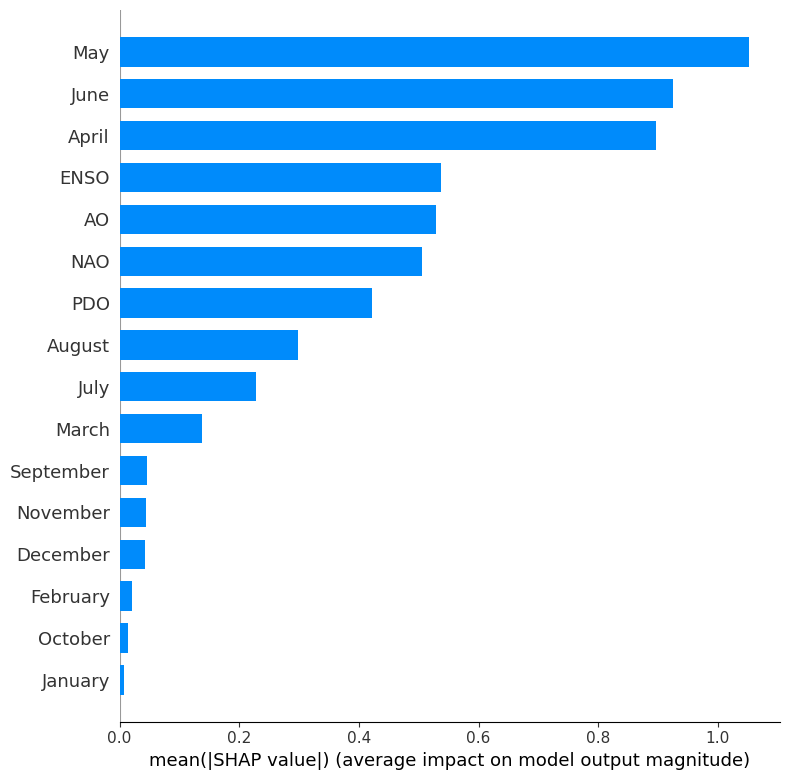

In [194]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model_month)
shap_values = explainer.shap_values(X_with_month)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_with_month, show=False)
plt.tight_layout()
plt.show()

# bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_with_month, plot_type="bar", show=False)
plt.tight_layout()
plt.show()


7\. Create a SHAP Feature Dependence for the ENSO index.

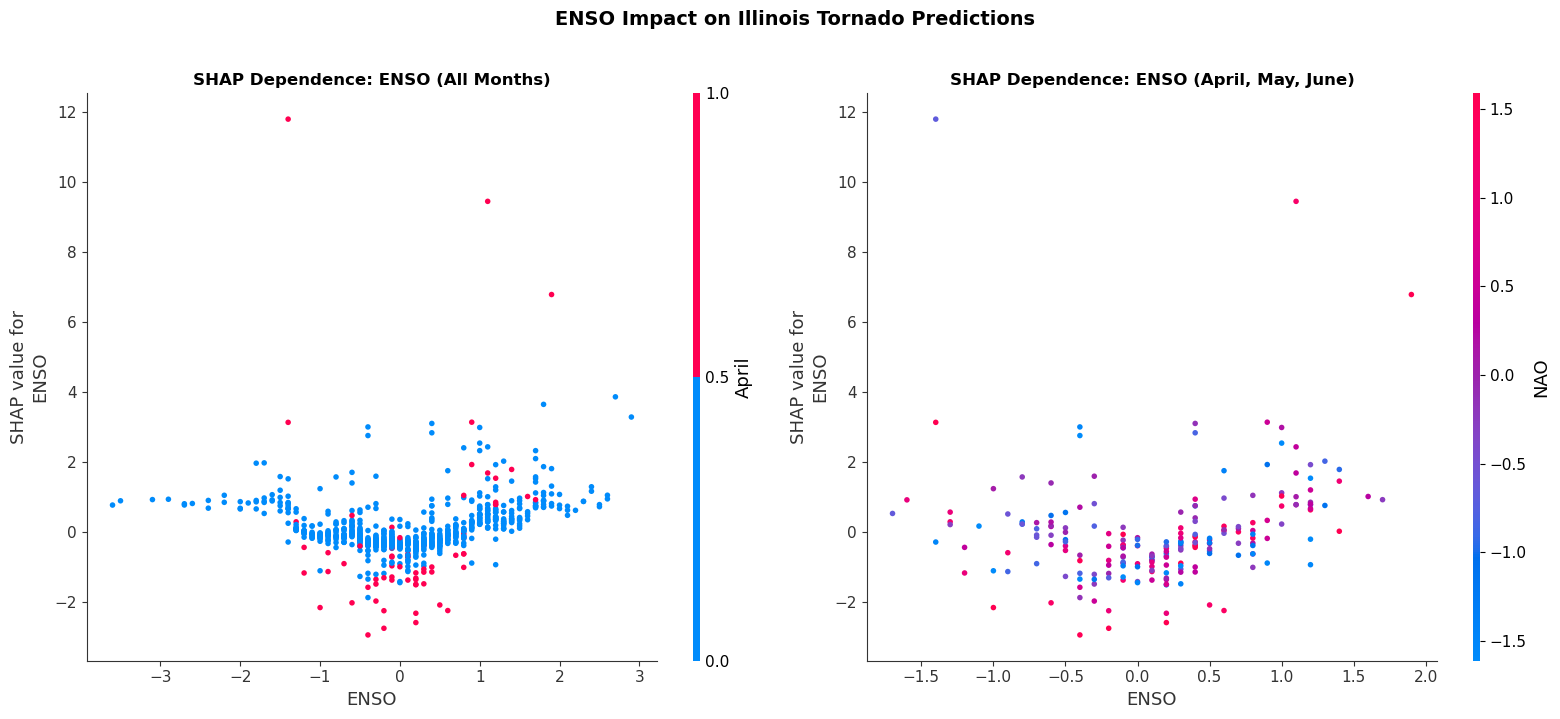

In [195]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# All data
shap.dependence_plot(
    'ENSO',
    shap_values,
    X_with_month,
    interaction_index="auto",
    show=False,
    ax=axes[0]
)
axes[0].set_title('SHAP Dependence: ENSO (All Months)', fontsize=12, fontweight='bold')

# Only April, May, June
tornado_season_mask = (X_with_month['April'] == 1) | (X_with_month['May'] == 1) | (X_with_month['June'] == 1)
X_season = X_with_month[tornado_season_mask]
shap_season = shap_values[tornado_season_mask]

shap.dependence_plot(
    'ENSO',
    shap_season,
    X_season,
    interaction_index="auto",
    show=False,
    ax=axes[1]
)
axes[1].set_title('SHAP Dependence: ENSO (April, May, June)', fontsize=12, fontweight='bold')

plt.suptitle('ENSO Impact on Illinois Tornado Predictions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


8\. Any observations on the importance of the various features in your model from the XAI techniques you tried?

### MDI  
From a previous cell, we have:  
MDI Importance (Top 5):  
1. AO                  : 0.222587  
2. NAO                 : 0.217895  
3. PDO                 : 0.179422  
4. ENSO                : 0.171159  
5. May                 : 0.069193  

This means that **the climate variables were used often** in the tree splitting of Random Forest. 

### Permutatuion Importance  
From a previous cell, we have:   
Permutation Importance (Top 5):  
1. May                 : 0.445363  
2. April               : 0.382388  
3. ENSO                : 0.368192  
4. AO                  : 0.358792  
5. NAO                 : 0.327298  

This means that **removing months had a strong impact - spring months are more important than climate variables**.  

### SHAP Values  

April, May, and June were consistently strong predictors of increased tornado probability. **Tornados are very seasonal**. The climate indices had a more mixed effect. I don't think they exhibited a strong enough pattern to draw any conclusions.